NOTEBOOK 5: RQ5 - SENSITIVITY TO EVALUATION METRICS (FIXED)

[1] Loading attached dataset...
✅ Loaded: autoscout24_16and10200.csv
Original dataset shape: (10200, 16)
Original columns: ['mileage_km', 'power_hp', 'fuel_category', 'price', 'model', 'body_type', 'transmission', 'power_kw', 'cylinders_volume_cc', 'weight_kg', 'is_used', 'registration_date', 'vehicle_type', 'nr_doors', 'vehicle_age', 'brand_premium']

[2] DIAGNOSTIC: Checking data before cleaning...

Target column check:
  ✅ 'price' column found
  Price sample: [164900.0, 62890.0, 96350.0]
  Price data type: float64

Checking for string values in numeric columns:
  mileage_km: ['4,000 km', '15,000 km'] (type: object)
  power_hp: [421.0, 197.0] (type: float64)
  vehicle_age: [1.0, 0.0] (type: float64)
  brand_premium: [2.6285702253235685, 2.6285702253235685] (type: float64)

[3] Cleaning data...
✅ Cleaned mileage_km
✅ Cleaned weight_kg
✅ Converted power_hp to numeric
✅ Converted power_kw to numeric
✅ Converted cylinders_volum

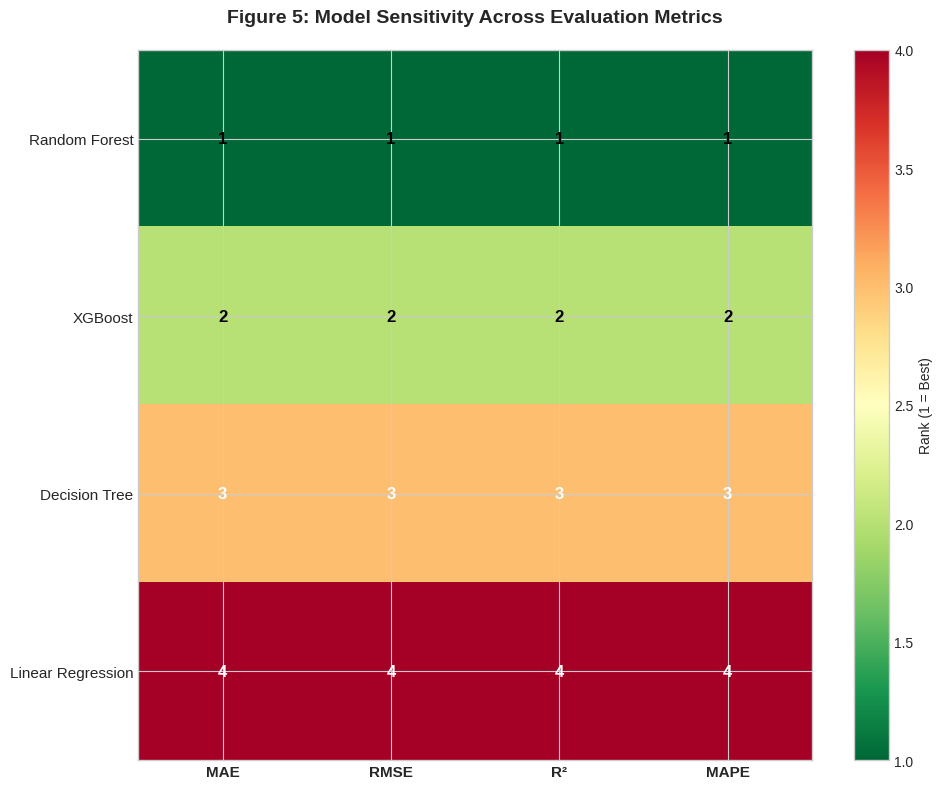

✅ Saved: /kaggle/working/Figure5_Metric_Sensitivity.pdf

[12] Creating alternative Figure 5b - Bar Chart...


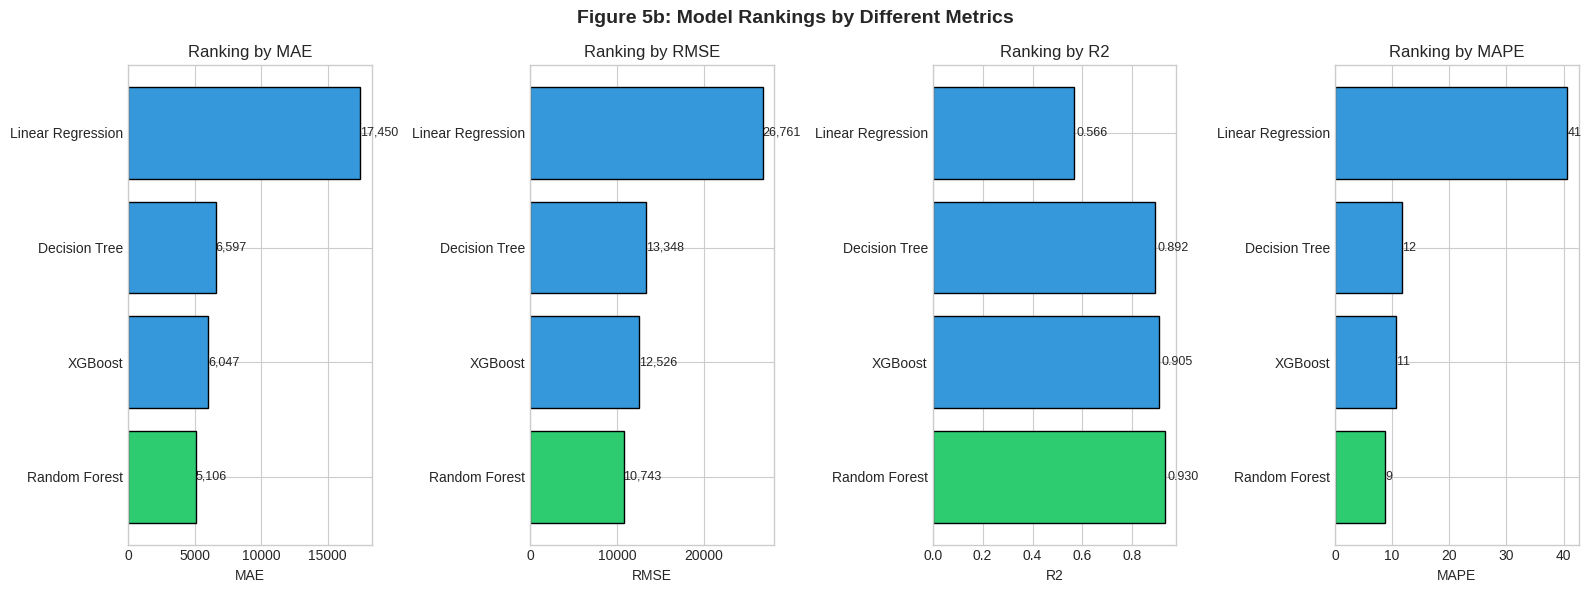

✅ Saved: /kaggle/working/Figure5b_Metric_Ranking_Bars.pdf

NOTEBOOK 5 COMPLETE

🏆 Summary:
   Best by R²: Random Forest (0.9300)
   Best by MAE: Random Forest (€5,106)
   Best by MAPE: Random Forest (8.8%)

📁 Output saved to: /kaggle/working
   - TableV_Metric_Rankings.csv
   - Figure5_Metric_Sensitivity.pdf
   - Figure5b_Metric_Ranking_Bars.pdf


In [1]:
# ==============================================================================
# NOTEBOOK 5: RQ5 - SENSITIVITY TO EVALUATION METRICS (FIXED)
# Dataset: carsmarket analysis (attached via Data tab)
# Kernel: cars-marketanalysis-rq5
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Install XGBoost if needed
try:
    import xgboost
except ImportError:
    !pip install xgboost -q
    import xgboost

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 8)

print("=" * 70)
print("NOTEBOOK 5: RQ5 - SENSITIVITY TO EVALUATION METRICS (FIXED)")
print("=" * 70)

# ==============================================================================
# STEP 1: LOAD DATASET
# ==============================================================================
print("\n[1] Loading attached dataset...")

input_dir = '/kaggle/input'
df = None
file_found = None

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(root, file))
            file_found = file
            print(f"✅ Loaded: {file}")
            break
    if df is not None:
        break

if df is None:
    raise FileNotFoundError("No dataset attached. Please add your dataset via the Data tab.")

print(f"Original dataset shape: {df.shape}")
print(f"Original columns: {df.columns.tolist()}")

# ==============================================================================
# STEP 2: DIAGNOSTIC - Check Data Before Cleaning
# ==============================================================================
print("\n[2] DIAGNOSTIC: Checking data before cleaning...")

print(f"\nTarget column check:")
if 'price' in df.columns:
    print(f"  ✅ 'price' column found")
    print(f"  Price sample: {df['price'].head(3).tolist()}")
    print(f"  Price data type: {df['price'].dtype}")
else:
    print(f"  ❌ 'price' column NOT found")
    print(f"  Available columns: {df.columns.tolist()}")
    # Try to find price-like column
    for col in df.columns:
        if 'price' in col.lower():
            print(f"     Did you mean: '{col}'?")
            df.rename(columns={col: 'price'}, inplace=True)
            print(f"     Renamed '{col}' to 'price'")
            break

print(f"\nChecking for string values in numeric columns:")
for col in ['mileage_km', 'power_hp', 'vehicle_age', 'brand_premium']:
    if col in df.columns:
        sample = df[col].head(2).tolist()
        print(f"  {col}: {sample} (type: {df[col].dtype})")

# ==============================================================================
# STEP 3: CLEAN DATA (MORE ROBUST)
# ==============================================================================
print("\n[3] Cleaning data...")

def clean_mileage(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

def clean_weight(value):
    if isinstance(value, str):
        cleaned = re.sub(r'[^\d.]', '', value.replace(',', ''))
        try:
            return float(cleaned)
        except:
            return np.nan
    return value

# Clean specific columns if they exist
if 'mileage_km' in df.columns:
    df['mileage_km'] = df['mileage_km'].apply(clean_mileage)
    print("✅ Cleaned mileage_km")

if 'weight_kg' in df.columns:
    df['weight_kg'] = df['weight_kg'].apply(clean_weight)
    print("✅ Cleaned weight_kg")

# Convert all potential numeric columns
potential_numeric = ['power_hp', 'power_kw', 'cylinders_volume_cc', 'nr_doors', 
                      'vehicle_age', 'brand_premium', 'price']
for col in potential_numeric:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"✅ Converted {col} to numeric")

# Drop rows with missing values in target or key features
key_features = ['price', 'mileage_km', 'power_hp', 'vehicle_age', 'brand_premium']
available_keys = [f for f in key_features if f in df.columns]

print(f"\nUsing key features: {available_keys}")
df_clean = df.dropna(subset=available_keys)

print(f"\nDataset shape after cleaning: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,}")

if df_clean.shape[0] == 0:
    print("\n❌ ERROR: No rows remain after cleaning!")
    print("Please check your data. Here's a sample of raw data:")
    print(df.head())
    raise ValueError("Empty dataset after cleaning")

# ==============================================================================
# STEP 4: PREPARE FEATURES AND TARGET
# ==============================================================================
print("\n[4] Preparing features and target...")

target_col = 'price'
y = df_clean[target_col]
print(f"Target variable: {target_col}")
print(f"Target range: €{y.min():,.0f} - €{y.max():,.0f}")

# Select only numeric features (exclude target and non-numeric)
feature_cols = [col for col in df_clean.columns if col != target_col and df_clean[col].dtype in ['int64', 'float64']]
X = df_clean[feature_cols].copy()

print(f"Using {len(feature_cols)} numeric features")
print(f"Features: {feature_cols}")

if X.shape[0] == 0:
    print("\n❌ ERROR: No features available!")
    raise ValueError("No features after cleaning")

# ==============================================================================
# STEP 5: TRAIN-TEST SPLIT
# ==============================================================================
print("\n[5] Train-test split...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Test samples: {X_test.shape[0]:,}")

if X_train.shape[0] == 0:
    raise ValueError("No training samples!")

# ==============================================================================
# STEP 6: FEATURE SCALING
# ==============================================================================
print("\n[6] Feature scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Scaling complete")

# ==============================================================================
# STEP 7: DEFINE MODELS
# ==============================================================================
print("\n[7] Defining models...")

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, verbosity=0)
}

print(f"✅ Defined {len(models)} models")

# ==============================================================================
# STEP 8: TRAIN AND COLLECT METRICS
# ==============================================================================
print("\n[8] Training models and collecting metrics...")

def get_all_metrics(model, X_train, y_train, X_test, y_test, name):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return {
            'Model': name,
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred),
            'MAPE': np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100
        }
    except Exception as e:
        print(f"    Error with {name}: {str(e)[:80]}")
        return None

results = []
for name, model in models.items():
    print(f"  Training {name}...")
    result = get_all_metrics(model, X_train_scaled, y_train, X_test_scaled, y_test, name)
    if result is not None:
        results.append(result)
        print(f"    ✓ R² = {result['R2']:.4f}")

if len(results) == 0:
    print("\n❌ No models trained successfully!")
    raise ValueError("All models failed to train")

results_df = pd.DataFrame(results)

# ==============================================================================
# STEP 9: CREATE RANKINGS
# ==============================================================================
print("\n[9] Creating rankings...")

for metric in ['MAE', 'RMSE', 'R2', 'MAPE']:
    ascending = metric != 'R2'
    results_df[f'Rank_{metric}'] = results_df[metric].rank(ascending=ascending, method='dense').astype(int)

results_df = results_df.sort_values('R2', ascending=False)

# ==============================================================================
# STEP 10: CREATE TABLE V
# ==============================================================================
print("\n[10] Creating Table V...")

print("\n" + "-" * 85)
print("TABLE V: Model Ranking Under Different Evaluation Metrics")
print("-" * 85)
print(f"{'Model':<20} {'MAE (€)':<15} {'RMSE (€)':<15} {'R²':<12} {'MAPE (%)':<12}")
print("-" * 85)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} €{row['MAE']:>12,.0f} €{row['RMSE']:>12,.0f} "
          f"{row['R2']:>10.4f} {row['MAPE']:>10.1f}%")
print("-" * 85)

print("\n" + "-" * 70)
print("RANKINGS SUMMARY")
print("-" * 70)
print(f"{'Model':<20} {'MAE Rank':<12} {'RMSE Rank':<12} {'R² Rank':<12} {'MAPE Rank':<12}")
print("-" * 70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<20} {row['Rank_MAE']:<12} {row['Rank_RMSE']:<12} "
          f"{row['Rank_R2']:<12} {row['Rank_MAPE']:<12}")
print("-" * 70)

output_dir = '/kaggle/working'
results_df[['Model', 'Rank_MAE', 'Rank_RMSE', 'Rank_R2', 'Rank_MAPE']].to_csv(
    f'{output_dir}/TableV_Metric_Rankings.csv', index=False)
print(f"\n✅ Saved: {output_dir}/TableV_Metric_Rankings.csv")

# ==============================================================================
# STEP 11: CREATE FIGURE 5 - HEATMAP
# ==============================================================================
print("\n[11] Creating Figure 5...")

# Prepare matrix for heatmap
rank_matrix = results_df[['Rank_MAE', 'Rank_RMSE', 'Rank_R2', 'Rank_MAPE']].values
models_list = results_df['Model'].values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(models))

ax.set_xticks(range(4))
ax.set_yticks(range(len(models_list)))
ax.set_xticklabels(['MAE', 'RMSE', 'R²', 'MAPE'], fontsize=11, fontweight='bold')
ax.set_yticklabels(models_list, fontsize=11)
ax.set_title('Figure 5: Model Sensitivity Across Evaluation Metrics', 
             fontsize=14, fontweight='bold', pad=20)

# Add rank numbers
for i in range(len(models_list)):
    for j in range(4):
        color = 'white' if rank_matrix[i, j] > len(models)/2 else 'black'
        ax.text(j, i, str(rank_matrix[i, j]), ha='center', va='center', 
               color=color, fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1 = Best)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_dir}/Figure5_Metric_Sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{output_dir}/Figure5_Metric_Sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure5_Metric_Sensitivity.pdf")

# ==============================================================================
# STEP 12: CREATE FIGURE 5B - BAR CHART (Alternative)
# ==============================================================================
print("\n[12] Creating alternative Figure 5b - Bar Chart...")

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

metrics_to_plot = ['MAE', 'RMSE', 'R2', 'MAPE']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R2'))
    colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(sorted_df))]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='black')
    
    ax.set_xlabel(metric, fontsize=10)
    ax.set_title(f'Ranking by {metric}', fontsize=12)
    
    # Add value labels
    for bar, val in zip(bars, sorted_df[metric]):
        if metric == 'R2':
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{val:.3f}', va='center', fontsize=9)
        else:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{val:,.0f}', va='center', fontsize=9)

plt.suptitle('Figure 5b: Model Rankings by Different Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/Figure5b_Metric_Ranking_Bars.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_dir}/Figure5b_Metric_Ranking_Bars.pdf")

# ==============================================================================
# SUMMARY
# ==============================================================================
print("\n" + "=" * 70)
print("NOTEBOOK 5 COMPLETE")
print("=" * 70)
print(f"\n🏆 Summary:")
print(f"   Best by R²: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['R2']:.4f})")
print(f"   Best by MAE: {results_df.iloc[results_df['MAE'].argmin()]['Model']} (€{results_df['MAE'].min():,.0f})")
print(f"   Best by MAPE: {results_df.iloc[results_df['MAPE'].argmin()]['Model']} ({results_df['MAPE'].min():.1f}%)")
print(f"\n📁 Output saved to: {output_dir}")
print("   - TableV_Metric_Rankings.csv")
print("   - Figure5_Metric_Sensitivity.pdf")
print("   - Figure5b_Metric_Ranking_Bars.pdf")
print("=" * 70)